# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset didapat dari Kaggle dengan link berikut:
https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction

Tugas atau Projek kali ini akan mempresiksi kalori yang dibakar selama olahraga

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import zipfile
from google.colab import userdata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
import numpy as np
from scipy import stats

In [2]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
!kaggle datasets download -d ruchikakumbhar/calories-burnt-prediction

Dataset URL: https://www.kaggle.com/datasets/ruchikakumbhar/calories-burnt-prediction
License(s): CC0-1.0
100% 236k/236k [00:00<00:00, 54.2MB/s]



In [4]:
nama_zip = "/content/calories-burnt-prediction.zip"
if os.path.exists(nama_zip):
    with zipfile.ZipFile(nama_zip, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    os.remove(nama_zip)
else:
    print(f"File {nama_zip} tidak ditemukan.")

In [5]:
data = pd.read_csv("/content/calories.csv")
data.head(5)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
data.drop("User_ID",axis=1,inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [8]:
data.describe(include="all")

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,NaN,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,NaN,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,NaN,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,NaN,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,NaN,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000


In [9]:
data_eda = data.copy()
data_eda["Gender"] = data_eda["Gender"].apply(lambda x: 1 if x=="male" else 0)
data_eda.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0


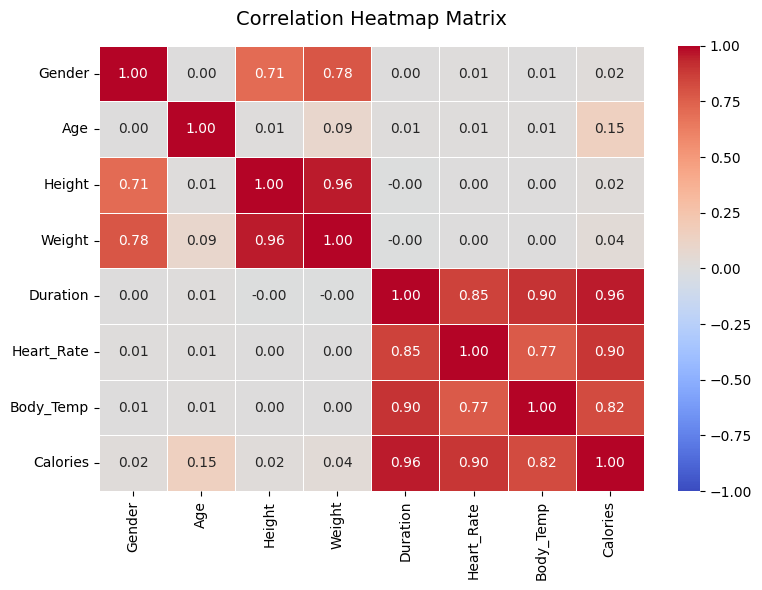

In [10]:
corr_matrix = data_eda.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [11]:
print("\nDistribusi Gender:")
print(data['Gender'].value_counts(normalize=True)*100)


Distribusi Gender:
Gender
female    50.353333
male      49.646667
Name: proportion, dtype: float64


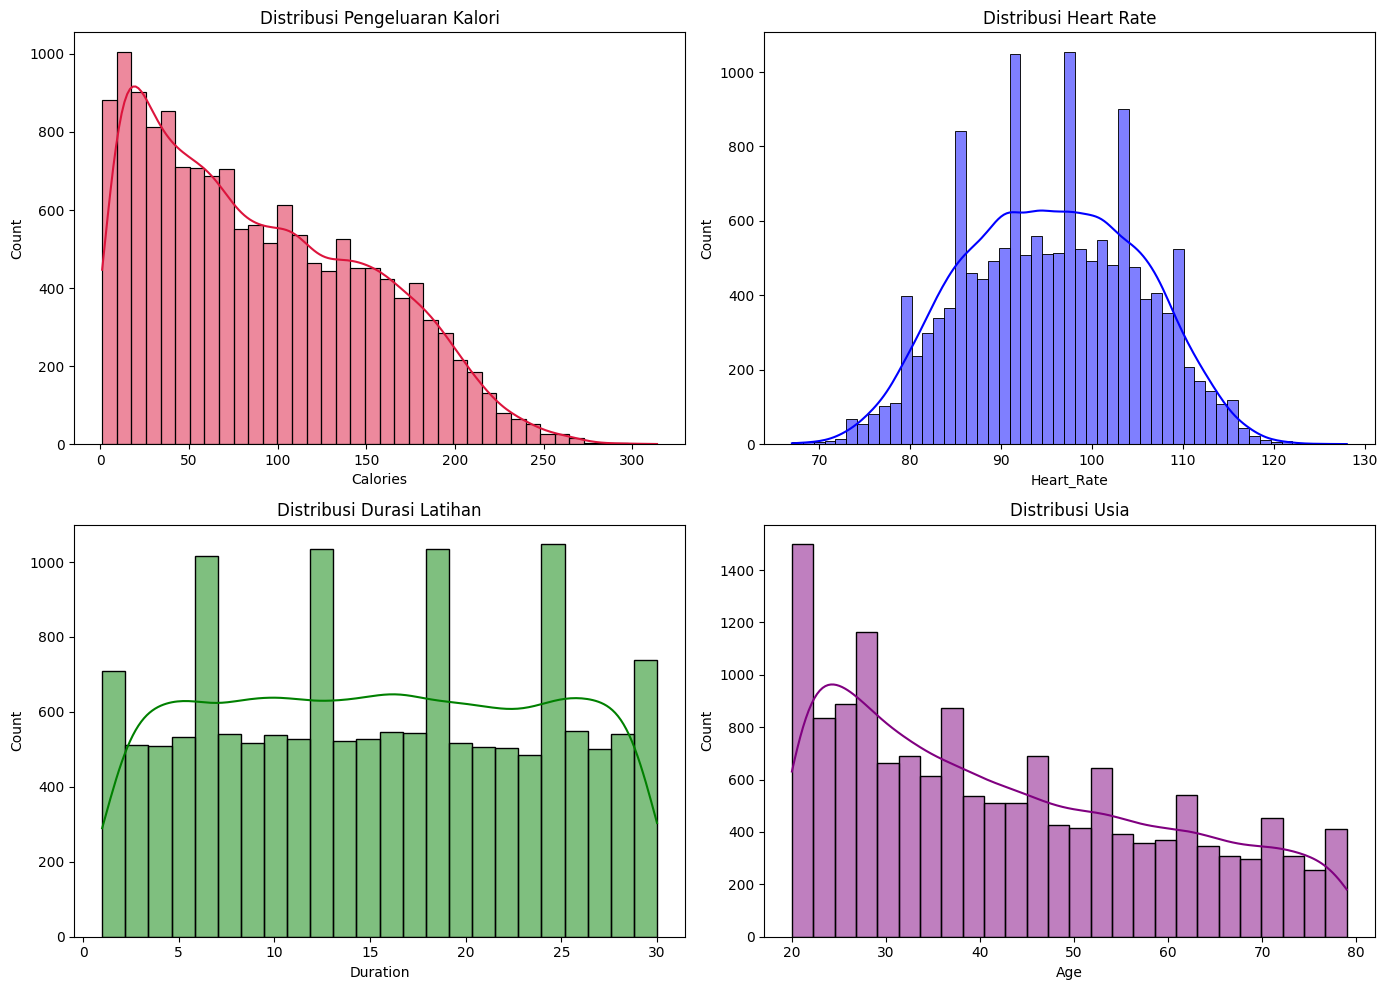

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data_eda['Calories'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Distribusi Pengeluaran Kalori')

sns.histplot(data_eda['Heart_Rate'], kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Distribusi Heart Rate')

sns.histplot(data_eda['Duration'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribusi Durasi Latihan')

sns.histplot(data_eda['Age'], kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribusi Usia')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
data = data.drop_duplicates()

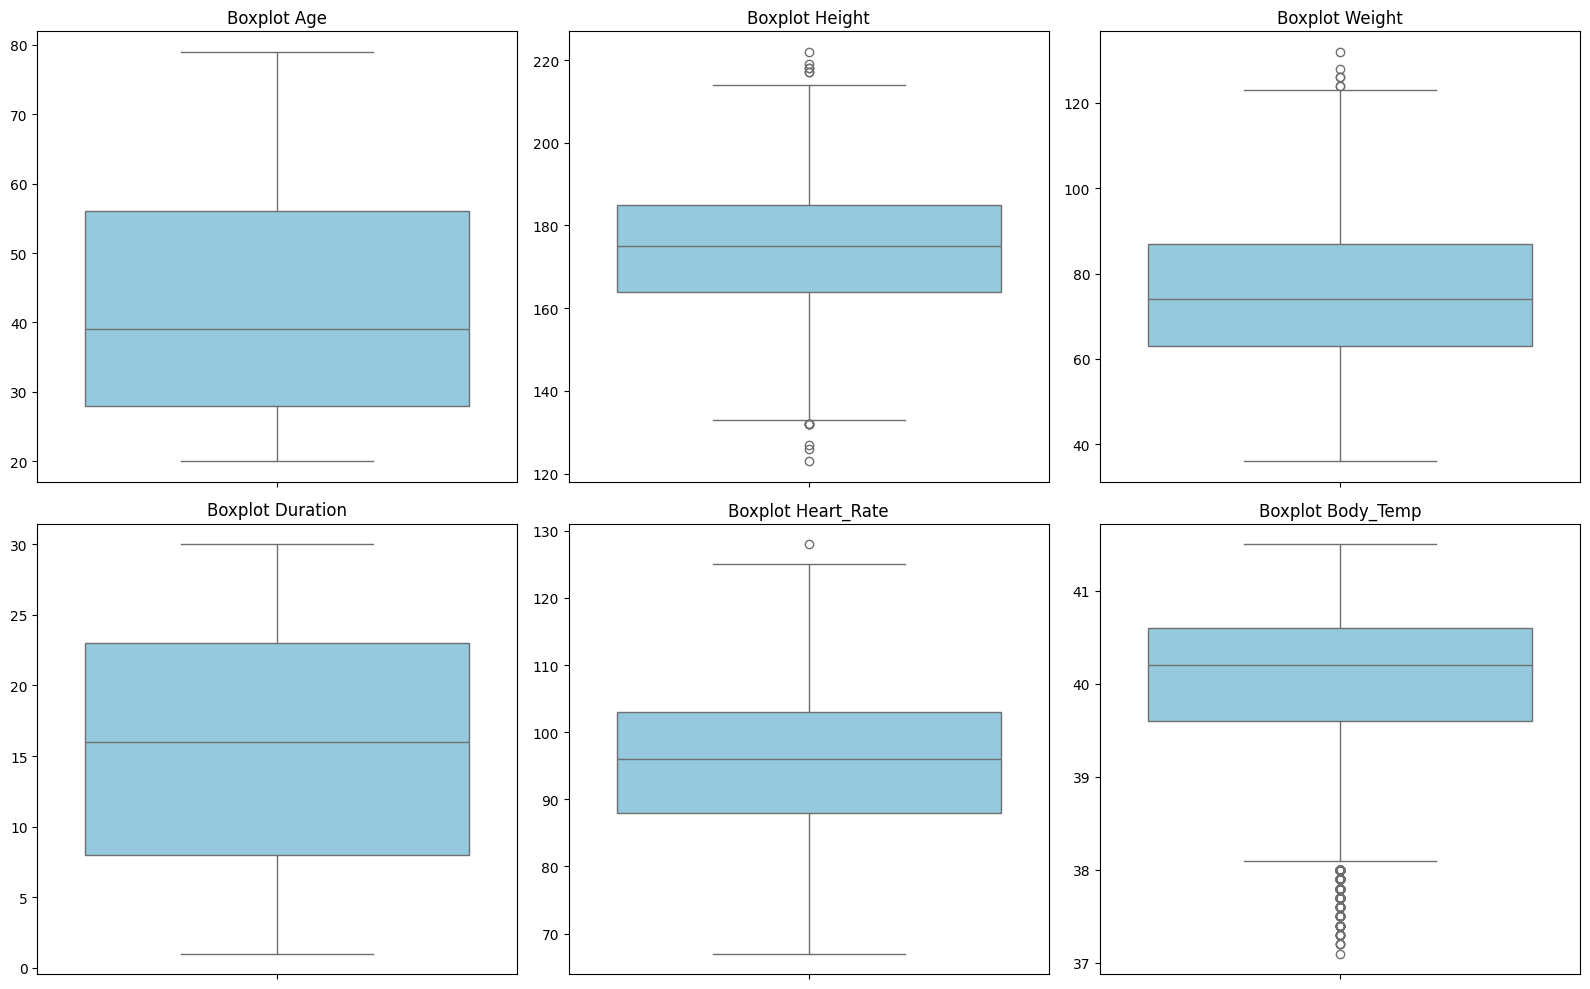

In [14]:
features_to_box = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_box):
    sns.boxplot(data=data_eda, y=feature, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {feature}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [15]:
data["Gender"] = data["Gender"].apply(lambda x: 1 if x=="male" else 0)

In [16]:
features_to_transform = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
pt = PowerTransformer(method='box-cox', standardize=True)
data_bc = pt.fit_transform(data[features_to_transform])
data_bc = pd.DataFrame(data_bc, columns=features_to_transform)

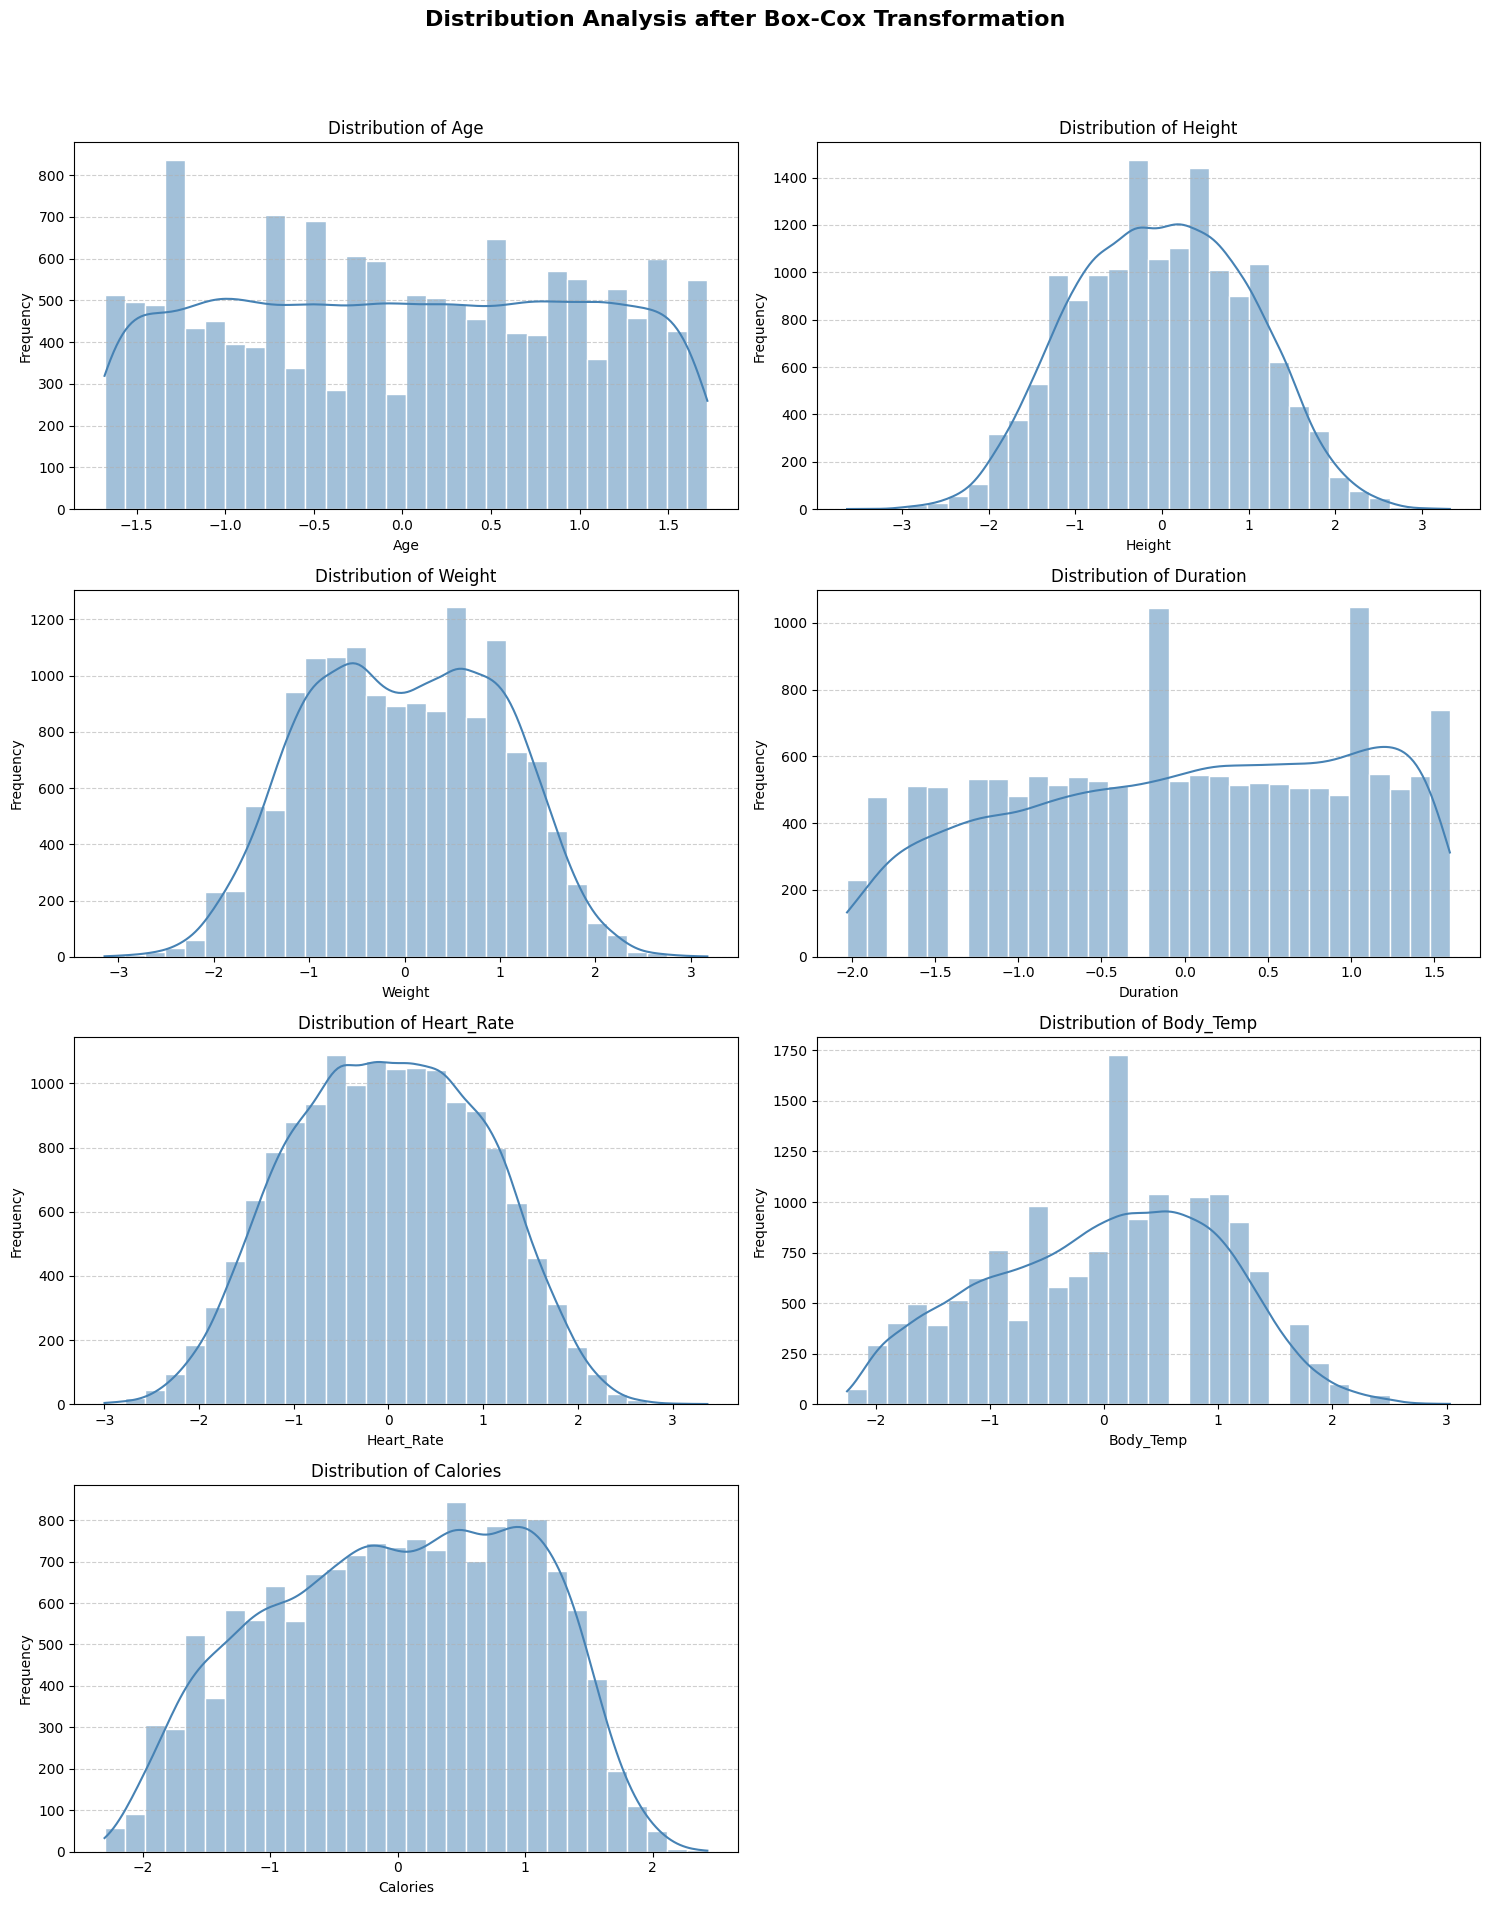

In [17]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle('Distribution Analysis after Box-Cox Transformation', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, item in enumerate(features_to_transform):
    sns.histplot(data_bc[item], kde=True, color='steelblue', bins=30, ax=axes[i], edgecolor='white')
    axes[i].set_title(f'Distribution of {item}', fontsize=12)
    axes[i].set_xlabel(item)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [18]:
def count_outliers(df, columns):
    outlier_report = {}
    total_rows = len(df)
    for item in columns:
        Q1 = df[item].quantile(0.25)
        Q3 = df[item].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[item] < lower_bound) | (df[item] > upper_bound)]
        outlier_report[item] = (len(outliers) / total_rows) * 100

    return pd.Series(outlier_report)

num_outlier = count_outliers(data, features_to_transform)
print("Percentage of outliers for each column (%)")
print(num_outlier)

Percentage of outliers for each column (%)
Age           0.000000
Height        0.093340
Weight        0.040003
Duration      0.000000
Heart_Rate    0.006667
Body_Temp     2.460164
Calories      0.026668
dtype: float64


In [19]:
data_clean = data_bc.copy()

features_with_outliers = ['Height', 'Weight', 'Heart_Rate']

for feature in features_with_outliers:
    Q1 = data_clean[feature].quantile(0.25)
    Q3 = data_clean[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data_clean = data_clean[(data_clean[feature] >= lower_bound) & (data_clean[feature] <= upper_bound)]

print(f"Jumlah data sebelum dibersihkan: {len(data_bc)}")
print(f"Jumlah data setelah outlier dibuang: {len(data_clean)}")
print(f"Total baris yang dihapus: {len(data_bc) - len(data_clean)}")

Jumlah data sebelum dibersihkan: 14999
Jumlah data setelah outlier dibuang: 14984
Total baris yang dihapus: 15


In [20]:
data_clean.to_csv("calories_preprocessing.csv", index=False)